In [ ]:
# Tratamiento de datos
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd

# Gráficos
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Preprocesado y modelado
# ------------------------------------------------------------------------------
#from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [ ]:
url = 'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/housingBOSTON-2.csv'
df = pd.read_csv(url,delimiter=',')

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns = "MEDV"),
                                        df['MEDV'],
                                        random_state = 123,test_size=0.2
                                    )

In [ ]:
X_train.shape,X_test.shape

((404, 13), (102, 13))

In [ ]:
# Creación del modelo
# ------------------------------------------------------------------------------
modelo = DecisionTreeRegressor(
            max_depth         = 4,
            random_state      = 123
          )

# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelo.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=123)

Profundidad del árbol: 4
Número de nodos terminales: 14


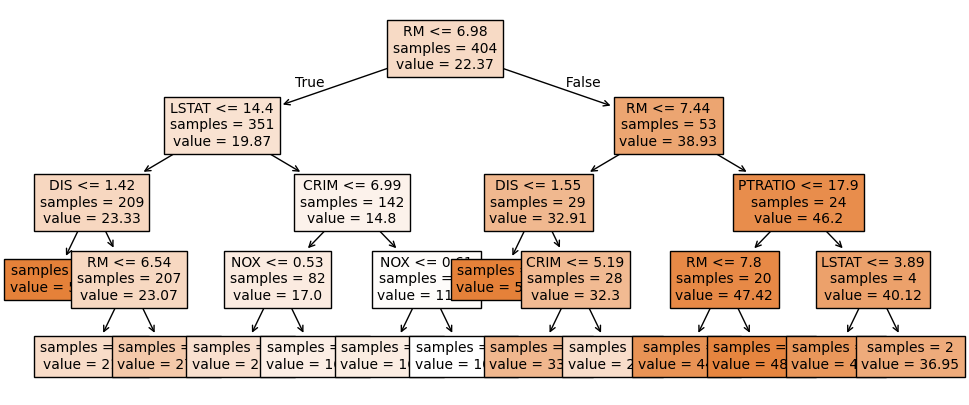

In [ ]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

print(f"Profundidad del árbol: {modelo.get_depth()}")
print(f"Número de nodos terminales: {modelo.get_n_leaves()}")
plot = plot_tree(
            decision_tree = modelo,
            feature_names = df.drop(columns = "MEDV").columns,
            class_names   = ['MEDV'],
            filled        = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

In [ ]:
texto_modelo = export_text(
                    decision_tree = modelo,
                    feature_names = list(df.drop(columns = "MEDV").columns)
               )
print(texto_modelo)

|--- RM <= 6.98
|   |--- LSTAT <= 14.40
|   |   |--- DIS <= 1.42
|   |   |   |--- value: [50.00]
|   |   |--- DIS >  1.42
|   |   |   |--- RM <= 6.54
|   |   |   |   |--- value: [21.62]
|   |   |   |--- RM >  6.54
|   |   |   |   |--- value: [27.61]
|   |--- LSTAT >  14.40
|   |   |--- CRIM <= 6.99
|   |   |   |--- NOX <= 0.53
|   |   |   |   |--- value: [20.34]
|   |   |   |--- NOX >  0.53
|   |   |   |   |--- value: [16.06]
|   |   |--- CRIM >  6.99
|   |   |   |--- NOX <= 0.61
|   |   |   |   |--- value: [16.57]
|   |   |   |--- NOX >  0.61
|   |   |   |   |--- value: [10.82]
|--- RM >  6.98
|   |--- RM <= 7.44
|   |   |--- DIS <= 1.55
|   |   |   |--- value: [50.00]
|   |   |--- DIS >  1.55
|   |   |   |--- CRIM <= 5.19
|   |   |   |   |--- value: [33.14]
|   |   |   |--- CRIM >  5.19
|   |   |   |   |--- value: [21.40]
|   |--- RM >  7.44
|   |   |--- PTRATIO <= 17.90
|   |   |   |--- RM <= 7.80
|   |   |   |   |--- value: [44.38]
|   |   |   |--- RM >  7.80
|   |   |   |   |--- v

In [ ]:
y_pred = modelo.predict(X_test)

In [ ]:
# Error de test del modelo inicia
#-------------------------------------------------------------------------------


In [ ]:
print("valor real --- valor de predicción")
for i in range(15):
  print("{:.2f}           {:.2f}".format(y_test.iloc[i],y_pred[i]))

valor real --- valor de predicción
15.00           50.00
26.60           27.61
45.40           48.72
20.80           21.62
34.90           27.61
21.90           36.95
28.70           21.62
7.20           10.82
20.00           20.34
32.20           33.14
24.10           21.62
18.50           21.62
13.50           16.06
27.00           21.62
23.10           16.06


In [ ]:
# probar con datos nuevos para ver que valor predice el modelo




In [ ]:
newDATA=df[['RM','LSTAT','DIS','CRIM']]
newDATA.head()

,RM,LSTAT,DIS,CRIM
0,6.575,4.98,4.0900,0.00632
1,6.421,9.14,4.9671,0.02731
2,7.185,4.03,4.9671,0.02729
3,6.998,2.94,6.0622,0.03237
4,7.147,5.33,6.0622,0.06905


In [ ]:
newDATA.shape

(506, 4)

In [ ]:
#DEBEN IMPLEMENTAR CON LAS 4 VARIABLES DE ENTRADA

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(newDATA,df['MEDV'],
                                        random_state = 123,test_size=0.2
                                    )

In [ ]:
X_train.shape,X_test.shape

((404, 4), (102, 4))

MODELO REGRESION LINEAL MULTIPLE

CARGANDO DATOS DE BOSTON HOUSING

Dimensiones del dataset: (506, 14)

Primeras 5 filas:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-nu

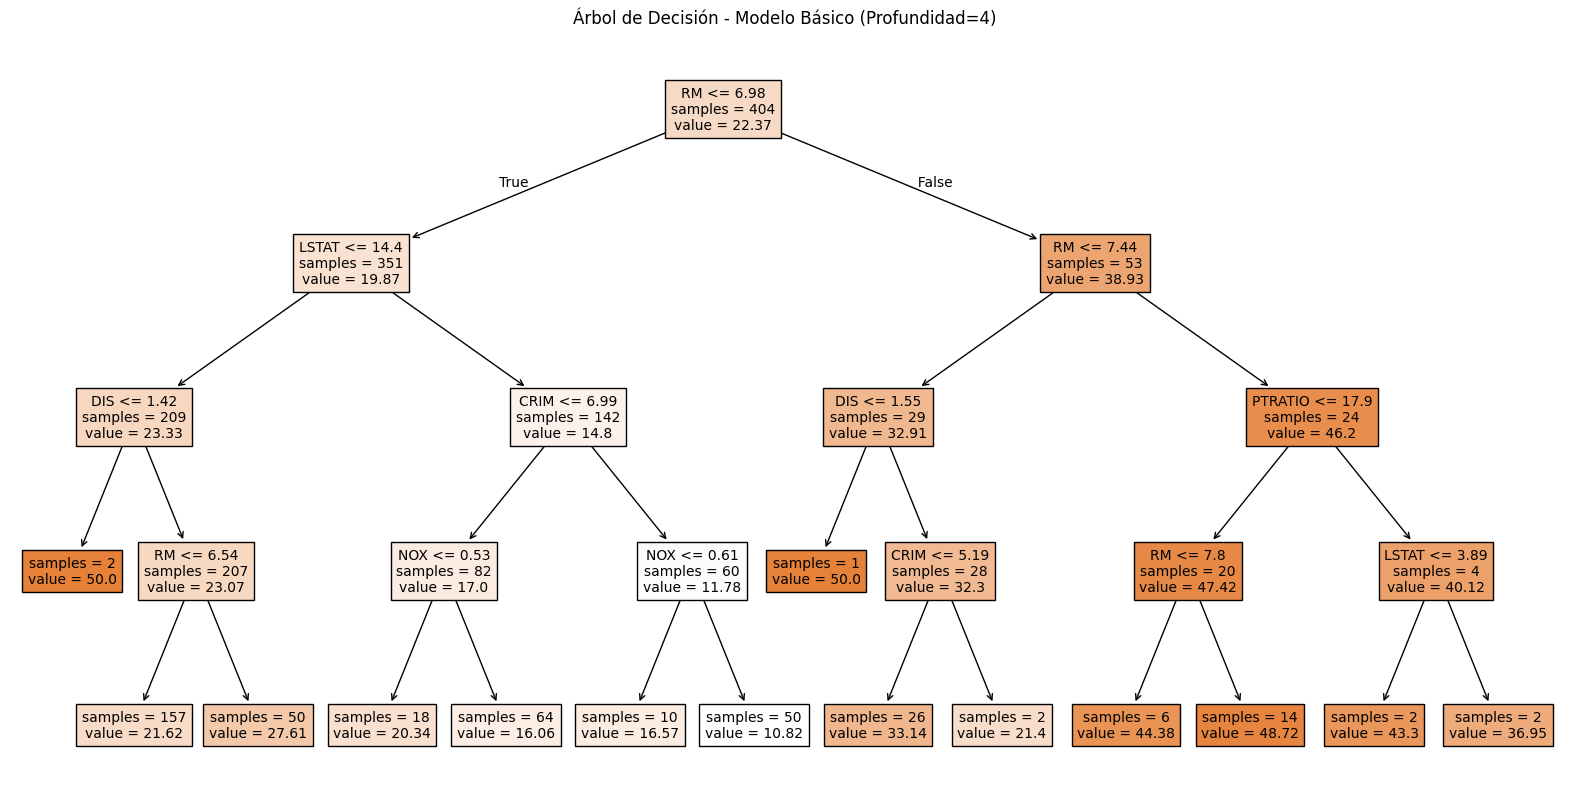


IMPORTANCIA DE VARIABLES


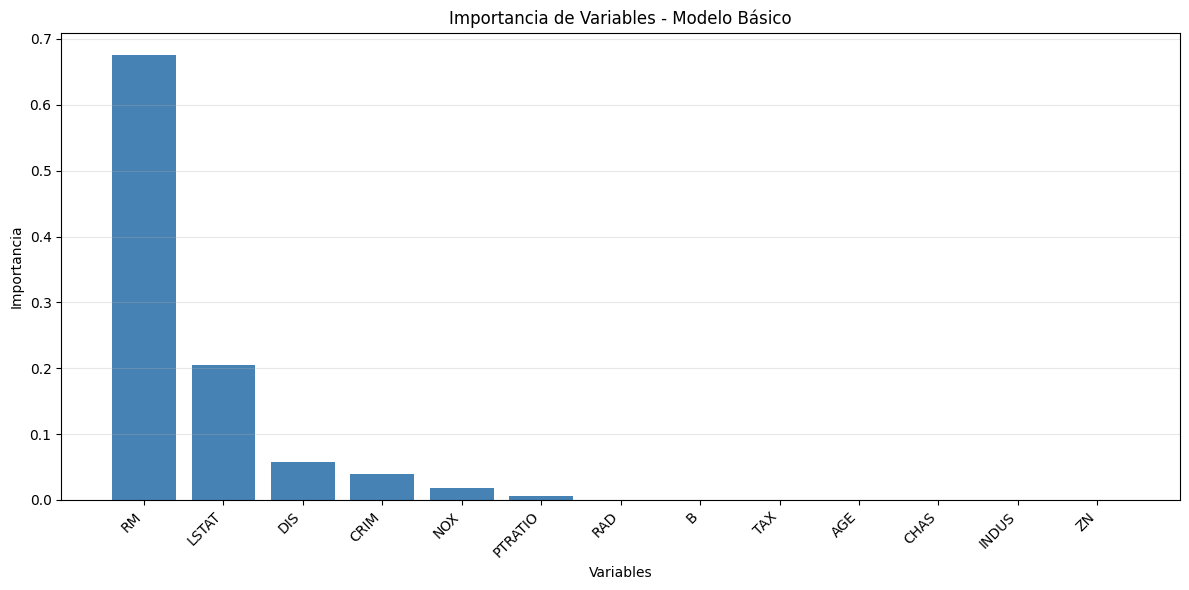


Ranking de importancia de variables:
----------------------------------------
 1. RM        : 0.6754
 2. LSTAT     : 0.2042
 3. DIS       : 0.0574
 4. CRIM      : 0.0396
 5. NOX       : 0.0176
 6. PTRATIO   : 0.0058
 7. RAD       : 0.0000
 8. B         : 0.0000
 9. TAX       : 0.0000
10. AGE       : 0.0000
11. CHAS      : 0.0000
12. INDUS     : 0.0000
13. ZN        : 0.0000

OPTIMIZANDO HIPERPARÁMETROS CON GRID SEARCH
Ejecutando Grid Search... (esto puede tomar unos momentos)

MEJORES PARÁMETROS ENCONTRADOS:
----------------------------------------
max_depth           : 7
max_features        : None
min_samples_leaf    : 6
min_samples_split   : 20

Mejor score (neg MSE): -18.4267

EVALUANDO MODELO OPTIMIZADO

RESULTADOS MODELO OPTIMIZADO:
MSE (Error Cuadrático Medio): 27.1236
RMSE (Raíz del Error Cuadrático Medio): 5.2080
R² (Coeficiente de Determinación): 0.6722
MAE (Error Absoluto Medio): 3.2483
Profundidad del árbol: 7
Número de hojas: 29

COMPARACIÓN DE MODELOS

Tabla de comparació

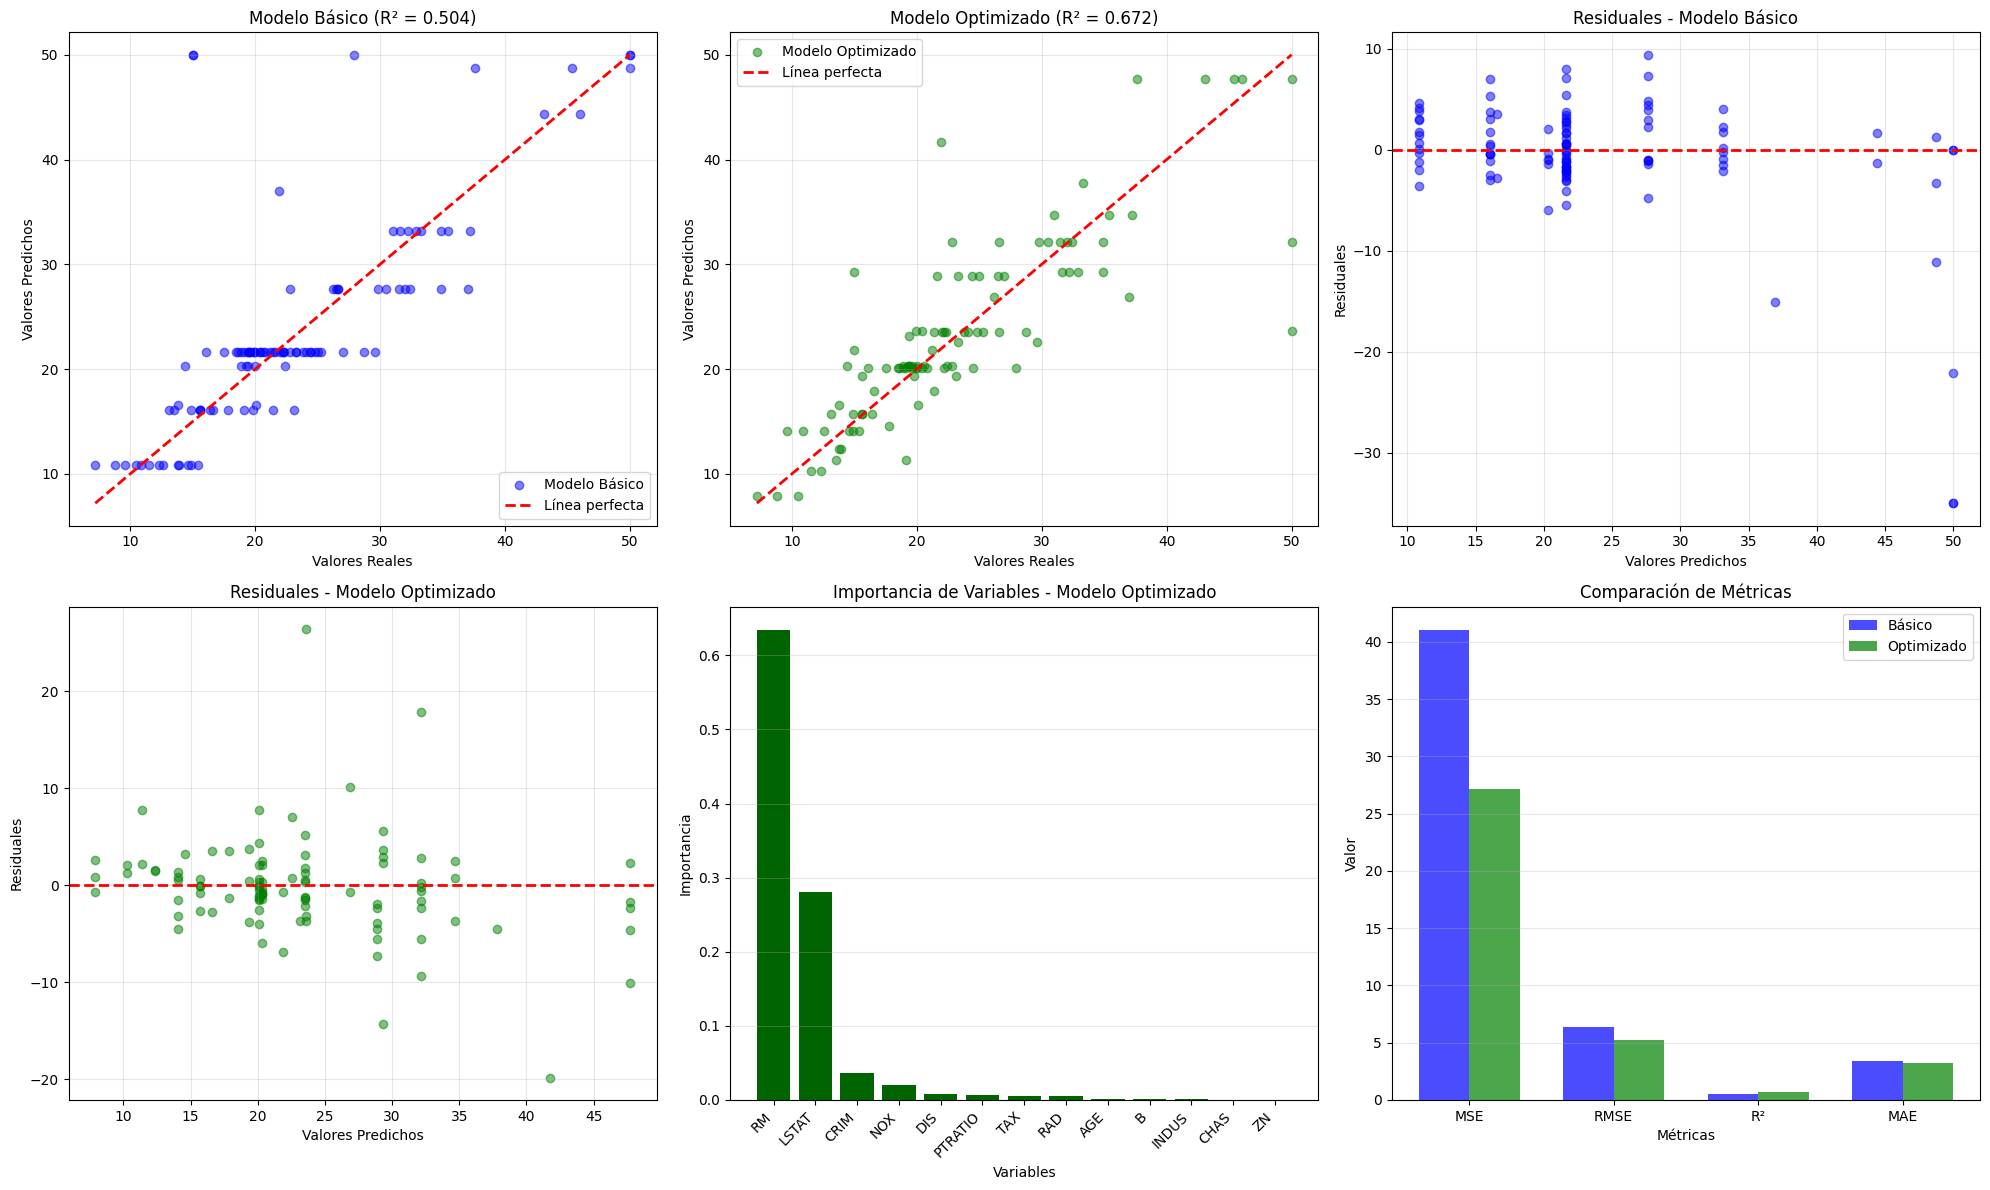


VISUALIZANDO ÁRBOL OPTIMIZADO


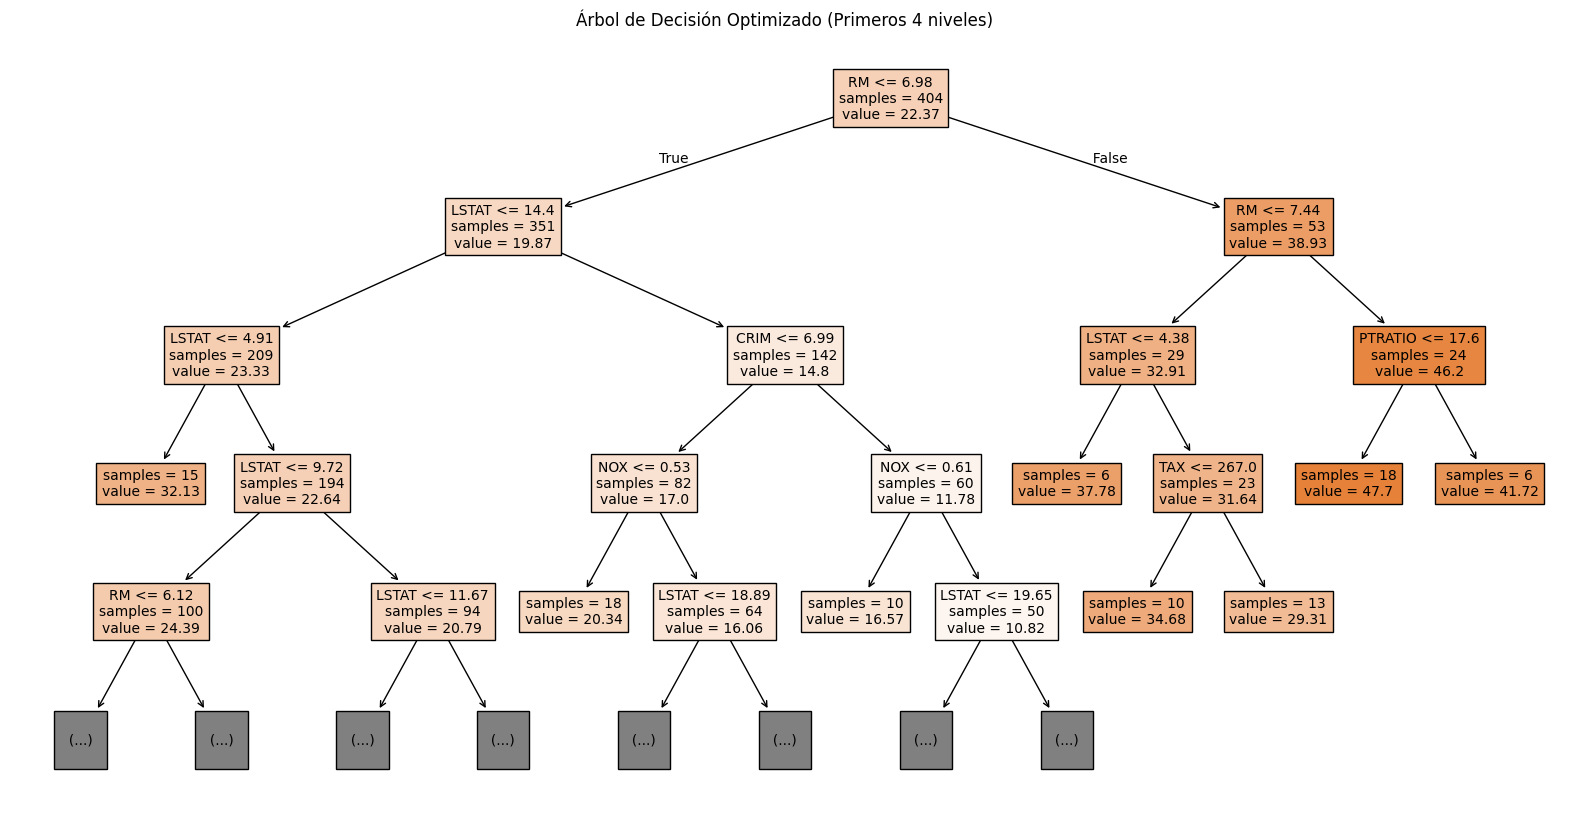


ANÁLISIS DETALLADO DE ERRORES

MODELO BÁSICO:
----------------------------------------
Error promedio: -0.5963
Error absoluto promedio: 3.4107
Desviación estándar de errores: 6.4079
Percentil 25 de error absoluto: 1.0260
Percentil 50 (mediana) de error absoluto: 2.0426
Percentil 75 de error absoluto: 3.6005
Máximo error absoluto: 35.0000
Mínimo error absoluto: 0.0000

MODELO OPTIMIZADO:
----------------------------------------
Error promedio: -0.2089
Error absoluto promedio: 3.2483
Desviación estándar de errores: 5.2295
Percentil 25 de error absoluto: 0.8905
Percentil 50 (mediana) de error absoluto: 2.1030
Percentil 75 de error absoluto: 3.7270
Máximo error absoluto: 26.3833
Mínimo error absoluto: 0.0643

EJEMPLO DE PREDICCIONES PARA NUEVOS DATOS

Predicciones para 5 muestras aleatorias:
--------------------------------------------------------------------------------
 Índice  Valor Real  Pred. Básico  Error Básico  Pred. Optimizado  Error Optimizado Mejor Modelo
      8        20.0   

In [1]:
# ============================================
# CONFIGURACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. CARGA Y EXPLORACIÓN DE DATOS
# ============================================
print("="*60)
print("CARGANDO DATOS DE BOSTON HOUSING")
print("="*60)

url = 'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/housingBOSTON-2.csv'
df = pd.read_csv(url, delimiter=',')

print(f"\nDimensiones del dataset: {df.shape}")
print(f"\nPrimeras 5 filas:")
print(df.head())
print(f"\nInformación del dataset:")
df.info()
print(f"\nEstadísticas descriptivas:")
print(df.describe())
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# ============================================
# 2. PREPARACIÓN DE DATOS
# ============================================
print("\n" + "="*60)
print("PREPARACIÓN DE DATOS")
print("="*60)

X = df.drop(columns='MEDV')
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123
)

print(f"\nDimensiones de los conjuntos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# ============================================
# 3. MODELO BÁSICO DE ÁRBOL DE DECISIÓN
# ============================================
print("\n" + "="*60)
print("ENTRENANDO MODELO BÁSICO")
print("="*60)

modelo_basico = DecisionTreeRegressor(
    max_depth=4,
    random_state=123
)

modelo_basico.fit(X_train, y_train)
y_pred_basico = modelo_basico.predict(X_test)

# Evaluación del modelo básico
mse_basico = mean_squared_error(y_test, y_pred_basico)
rmse_basico = np.sqrt(mse_basico)
r2_basico = r2_score(y_test, y_pred_basico)
mae_basico = mean_absolute_error(y_test, y_pred_basico)

print("\nRESULTADOS MODELO BÁSICO:")
print(f"MSE (Error Cuadrático Medio): {mse_basico:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_basico:.4f}")
print(f"R² (Coeficiente de Determinación): {r2_basico:.4f}")
print(f"MAE (Error Absoluto Medio): {mae_basico:.4f}")
print(f"Profundidad del árbol: {modelo_basico.get_depth()}")
print(f"Número de hojas: {modelo_basico.get_n_leaves()}")

# ============================================
# 4. VISUALIZACIÓN DEL ÁRBOL BÁSICO
# ============================================
print("\n" + "="*60)
print("VISUALIZANDO ÁRBOL DE DECISIÓN BÁSICO")
print("="*60)

plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree=modelo_basico,
    feature_names=X.columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2
)
plt.title("Árbol de Decisión - Modelo Básico (Profundidad=4)")
plt.show()

# ============================================
# 5. IMPORTANCIA DE VARIABLES
# ============================================
print("\n" + "="*60)
print("IMPORTANCIA DE VARIABLES")
print("="*60)

importancias = modelo_basico.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Importancia de Variables - Modelo Básico")
plt.bar(range(X.shape[1]), importancias[indices], align='center', color='steelblue')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45, ha='right')
plt.xlabel("Variables")
plt.ylabel("Importancia")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRanking de importancia de variables:")
print("-" * 40)
for i, (nombre, importancia) in enumerate(zip(X.columns[indices], importancias[indices])):
    print(f"{i+1:2d}. {nombre:10s}: {importancia:.4f}")

# ============================================
# 6. OPTIMIZACIÓN CON GRID SEARCH
# ============================================
print("\n" + "="*60)
print("OPTIMIZANDO HIPERPARÁMETROS CON GRID SEARCH")
print("="*60)

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

modelo_base = DecisionTreeRegressor(random_state=123)
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

print("Ejecutando Grid Search... (esto puede tomar unos momentos)")
grid_search.fit(X_train, y_train)

print("\nMEJORES PARÁMETROS ENCONTRADOS:")
print("-" * 40)
for param, value in grid_search.best_params_.items():
    print(f"{param:20s}: {value}")
print(f"\nMejor score (neg MSE): {grid_search.best_score_:.4f}")

# ============================================
# 7. MODELO OPTIMIZADO
# ============================================
print("\n" + "="*60)
print("EVALUANDO MODELO OPTIMIZADO")
print("="*60)

mejor_modelo = grid_search.best_estimator_
y_pred_optimizado = mejor_modelo.predict(X_test)

mse_optimizado = mean_squared_error(y_test, y_pred_optimizado)
rmse_optimizado = np.sqrt(mse_optimizado)
r2_optimizado = r2_score(y_test, y_pred_optimizado)
mae_optimizado = mean_absolute_error(y_test, y_pred_optimizado)

print("\nRESULTADOS MODELO OPTIMIZADO:")
print(f"MSE (Error Cuadrático Medio): {mse_optimizado:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_optimizado:.4f}")
print(f"R² (Coeficiente de Determinación): {r2_optimizado:.4f}")
print(f"MAE (Error Absoluto Medio): {mae_optimizado:.4f}")
print(f"Profundidad del árbol: {mejor_modelo.get_depth()}")
print(f"Número de hojas: {mejor_modelo.get_n_leaves()}")

# ============================================
# 8. COMPARACIÓN DE MODELOS
# ============================================
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

comparacion = pd.DataFrame({
    'Métrica': ['MSE', 'RMSE', 'R²', 'MAE', 'Profundidad', 'Hojas'],
    'Modelo Básico': [
        f"{mse_basico:.4f}",
        f"{rmse_basico:.4f}",
        f"{r2_basico:.4f}",
        f"{mae_basico:.4f}",
        modelo_basico.get_depth(),
        modelo_basico.get_n_leaves()
    ],
    'Modelo Optimizado': [
        f"{mse_optimizado:.4f}",
        f"{rmse_optimizado:.4f}",
        f"{r2_optimizado:.4f}",
        f"{mae_optimizado:.4f}",
        mejor_modelo.get_depth(),
        mejor_modelo.get_n_leaves()
    ]
})

print("\nTabla de comparación:")
print("-" * 60)
print(comparacion.to_string(index=False))

# ============================================
# 9. VISUALIZACIÓN DE RESULTADOS
# ============================================
print("\n" + "="*60)
print("VISUALIZACIÓN DE RESULTADOS")
print("="*60)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(20, 12))

# Subplot 1: Comparación de predicciones
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, y_pred_basico, alpha=0.5, label='Modelo Básico', color='blue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea perfecta')
ax1.set_xlabel('Valores Reales')
ax1.set_ylabel('Valores Predichos')
ax1.set_title(f'Modelo Básico (R² = {r2_basico:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Comparación de predicciones optimizadas
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(y_test, y_pred_optimizado, alpha=0.5, label='Modelo Optimizado', color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea perfecta')
ax2.set_xlabel('Valores Reales')
ax2.set_ylabel('Valores Predichos')
ax2.set_title(f'Modelo Optimizado (R² = {r2_optimizado:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Residuales modelo básico
ax3 = plt.subplot(2, 3, 3)
residuales_basico = y_test - y_pred_basico
ax3.scatter(y_pred_basico, residuales_basico, alpha=0.5, color='blue')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Valores Predichos')
ax3.set_ylabel('Residuales')
ax3.set_title('Residuales - Modelo Básico')
ax3.grid(True, alpha=0.3)

# Subplot 4: Residuales modelo optimizado
ax4 = plt.subplot(2, 3, 4)
residuales_optimizado = y_test - y_pred_optimizado
ax4.scatter(y_pred_optimizado, residuales_optimizado, alpha=0.5, color='green')
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Valores Predichos')
ax4.set_ylabel('Residuales')
ax4.set_title('Residuales - Modelo Optimizado')
ax4.grid(True, alpha=0.3)

# Subplot 5: Importancia de variables optimizado
ax5 = plt.subplot(2, 3, 5)
importancias_opt = mejor_modelo.feature_importances_
indices_opt = np.argsort(importancias_opt)[::-1]
ax5.bar(range(X.shape[1]), importancias_opt[indices_opt], align='center', color='darkgreen')
ax5.set_xticks(range(X.shape[1]))
ax5.set_xticklabels(X.columns[indices_opt], rotation=45, ha='right')
ax5.set_xlabel("Variables")
ax5.set_ylabel("Importancia")
ax5.set_title("Importancia de Variables - Modelo Optimizado")
ax5.grid(axis='y', alpha=0.3)

# Subplot 6: Comparación de métricas
ax6 = plt.subplot(2, 3, 6)
metricas = ['MSE', 'RMSE', 'R²', 'MAE']
valores_basico = [mse_basico, rmse_basico, r2_basico, mae_basico]
valores_optimizado = [mse_optimizado, rmse_optimizado, r2_optimizado, mae_optimizado]

x = np.arange(len(metricas))
width = 0.35
ax6.bar(x - width/2, valores_basico, width, label='Básico', color='blue', alpha=0.7)
ax6.bar(x + width/2, valores_optimizado, width, label='Optimizado', color='green', alpha=0.7)

ax6.set_xlabel('Métricas')
ax6.set_ylabel('Valor')
ax6.set_title('Comparación de Métricas')
ax6.set_xticks(x)
ax6.set_xticklabels(metricas)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# 10. VISUALIZACIÓN DEL ÁRBOL OPTIMIZADO
# ============================================
if mejor_modelo.get_depth() <= 8:
    print("\n" + "="*60)
    print("VISUALIZANDO ÁRBOL OPTIMIZADO")
    print("="*60)

    plt.figure(figsize=(20, 10))
    plot_tree(
        decision_tree=mejor_modelo,
        feature_names=X.columns,
        filled=True,
        impurity=False,
        fontsize=10,
        precision=2,
        max_depth=min(4, mejor_modelo.get_depth())  # Mostrar primeros niveles
    )
    plt.title(f"Árbol de Decisión Optimizado (Primeros {min(4, mejor_modelo.get_depth())} niveles)")
    plt.show()
else:
    print(f"\nEl árbol optimizado tiene {mejor_modelo.get_depth()} niveles de profundidad.")
    print("Para una mejor visualización, se recomienda limitar la profundidad.")

# ============================================
# 11. ANÁLISIS DE ERRORES DETALLADO
# ============================================
print("\n" + "="*60)
print("ANÁLISIS DETALLADO DE ERRORES")
print("="*60)

def analizar_errores_detallado(y_real, y_pred, nombre_modelo):
    errores = y_real - y_pred
    errores_abs = np.abs(errores)

    print(f"\n{nombre_modelo.upper()}:")
    print("-" * 40)
    print(f"Error promedio: {errores.mean():.4f}")
    print(f"Error absoluto promedio: {errores_abs.mean():.4f}")
    print(f"Desviación estándar de errores: {errores.std():.4f}")
    print(f"Percentil 25 de error absoluto: {np.percentile(errores_abs, 25):.4f}")
    print(f"Percentil 50 (mediana) de error absoluto: {np.percentile(errores_abs, 50):.4f}")
    print(f"Percentil 75 de error absoluto: {np.percentile(errores_abs, 75):.4f}")
    print(f"Máximo error absoluto: {errores_abs.max():.4f}")
    print(f"Mínimo error absoluto: {errores_abs.min():.4f}")

    return errores_abs

errores_basico = analizar_errores_detallado(y_test, y_pred_basico, "Modelo Básico")
errores_optimizado = analizar_errores_detallado(y_test, y_pred_optimizado, "Modelo Optimizado")

# ============================================
# 12. EJEMPLO DE PREDICCIONES
# ============================================
print("\n" + "="*60)
print("EJEMPLO DE PREDICCIONES PARA NUEVOS DATOS")
print("="*60)

# Seleccionar 5 muestras aleatorias del conjunto de prueba
np.random.seed(123)
indices_muestra = np.random.choice(len(X_test), 5, replace=False)

muestra_X = X_test.iloc[indices_muestra]
muestra_y_real = y_test.iloc[indices_muestra]

pred_basico_muestra = modelo_basico.predict(muestra_X)
pred_optimizado_muestra = mejor_modelo.predict(muestra_X)

resultados_muestra = pd.DataFrame({
    'Índice': indices_muestra,
    'Valor Real': muestra_y_real.values,
    'Pred. Básico': pred_basico_muestra.round(2),
    'Error Básico': (muestra_y_real.values - pred_basico_muestra).round(2),
    'Pred. Optimizado': pred_optimizado_muestra.round(2),
    'Error Optimizado': (muestra_y_real.values - pred_optimizado_muestra).round(2),
    'Mejor Modelo': np.where(
        np.abs(muestra_y_real.values - pred_basico_muestra) < np.abs(muestra_y_real.values - pred_optimizado_muestra),
        'Básico', 'Optimizado'
    )
})

print("\nPredicciones para 5 muestras aleatorias:")
print("-" * 80)
print(resultados_muestra.to_string(index=False))

# ============================================
# 13. RESUMEN FINAL
# ============================================
print("\n" + "="*60)
print("RESUMEN FINAL DEL MODELO")
print("="*60)

print(f"\nDATASET BOSTON HOUSING:")
print(f"• Total de muestras: {df.shape[0]}")
print(f"• Variables predictoras: {X.shape[1]}")
print(f"• Variable objetivo: MEDV (Valor medio de viviendas en miles de $)")

print(f"\nMEJOR MODELO OBTENIDO:")
print(f"• Tipo: Árbol de Decisión para Regresión")
print(f"• Profundidad óptima: {mejor_modelo.get_depth()}")
print(f"• Número de hojas: {mejor_modelo.get_n_leaves()}")
print(f"• R² alcanzado: {r2_optimizado:.4f}")
print(f"• Error RMSE: {rmse_optimizado:.4f} (en miles de $)")

print(f"\nINTERPRETACIÓN DEL MODELO:")
print(f"• El modelo puede explicar aproximadamente {r2_optimizado*100:.1f}% de la variabilidad en los precios")
print(f"• El error promedio de predicción es de ±{rmse_optimizado:.2f} miles de dólares")
print(f"• Variables más importantes: {X.columns[indices_opt][0]}, {X.columns[indices_opt][1]}")

print(f"\nRECOMENDACIONES:")
print("1. Considerar la profundidad del árbol para evitar sobreajuste")
print("2. Validar con más datos si es posible")
print("3. Considerar ensambles de árboles (Random Forest, Gradient Boosting)")
print("4. Analizar outliers que puedan estar afectando las predicciones")

# ============================================
# 14. EXPORTAR RESULTADOS (OPCIONAL)
# ============================================
print("\n" + "="*60)
print("EXPORTANDO RESULTADOS")
print("="*60)

# Crear DataFrame con resultados completos
resultados_completos = pd.DataFrame({
    'Muestra': range(len(y_test)),
    'Valor_Real': y_test.values,
    'Pred_Basico': y_pred_basico,
    'Pred_Optimizado': y_pred_optimizado,
    'Error_Basico': y_test.values - y_pred_basico,
    'Error_Optimizado': y_test.values - y_pred_optimizado
})

# Guardar resultados en CSV
resultados_completos.to_csv('resultados_arbol_boston.csv', index=False)
print("✓ Resultados guardados en 'resultados_arbol_boston.csv'")

# Guardar el mejor modelo
import joblib
joblib.dump(mejor_modelo, 'mejor_modelo_arbol_boston.pkl')
print("✓ Modelo optimizado guardado en 'mejor_modelo_arbol_boston.pkl'")

# Guardar métricas de evaluación
metricas_df = pd.DataFrame({
    'Metrica': ['MSE', 'RMSE', 'R2', 'MAE', 'Profundidad', 'Hojas'],
    'Modelo_Basico': [mse_basico, rmse_basico, r2_basico, mae_basico, modelo_basico.get_depth(), modelo_basico.get_n_leaves()],
    'Modelo_Optimizado': [mse_optimizado, rmse_optimizado, r2_optimizado, mae_optimizado, mejor_modelo.get_depth(), mejor_modelo.get_n_leaves()]
})
metricas_df.to_csv('metricas_modelos_boston.csv', index=False)
print("✓ Métricas guardadas en 'metricas_modelos_boston.csv'")

print("\n" + "="*60)
print("¡PROCESO COMPLETADO EXITOSAMENTE!")
print("="*60)